# Multiclass Classification with Logistic Regression using One-vs-Rest and One-vs-One Strategies

In this notebook, we'll:

* Use the Wine Quality dataset for multiclass classification.
* Implement Logistic Regression using One-vs-Rest (OvR) and One-vs-One (OvO) strategies.
* Compare the performance of both approaches.
* Utilize appropriate evaluation metrics.

Multiclass classification can be approached using strategies that decompose the problem into multiple binary classification tasks:

**One-vs-Rest (OvR):** Fits one classifier per class, with the samples of that class as positive samples and all other samples as negatives.

**One-vs-One (OvO):** Fits one classifier per pair of classes.

**Objective:** Build Logistic Regression classifiers using OvR and OvO strategies to predict wine quality ratings, and compare their performance.

# Import Libraries

In [30]:
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# Import SMOTE for handling imbalance
from imblearn.over_sampling import SMOTE

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


# Load and Explore the Data

We'll use the **Wine Quality** dataset from the UCI Machine Learning Repository.

## Load the Dataset

In [31]:
# Load the dataset directly from the URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')


## Explore the Dataset

In [32]:
# Display the first five rows
display(data.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Check for Missing Values

In [33]:
# Check for null values
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Observation:** No missing values in the dataset.

## Target Variable Distribution

In [34]:
# Distribution of the 'quality' variable
quality_counts = data['quality'].value_counts().sort_index()
print(quality_counts)


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


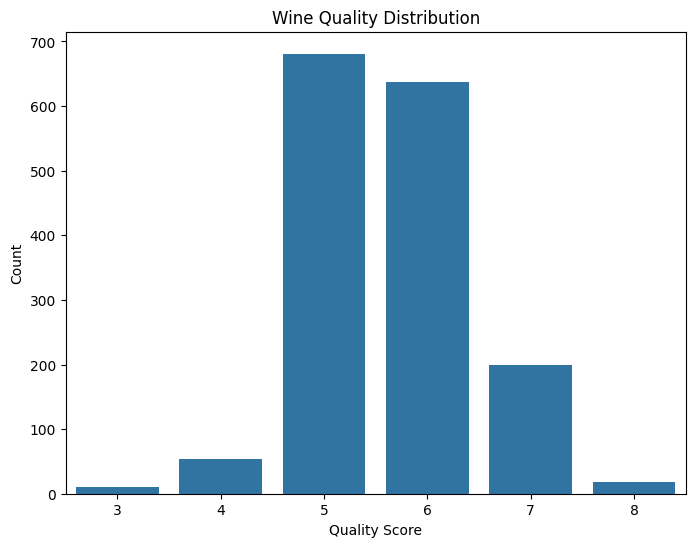

In [6]:
# Plot the distribution
plt.figure(figsize=(8,6))
sns.countplot(x='quality', data=data)
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()


**Observation:** The dataset is imbalanced with some quality scores being underrepresented.

# Data Preprocessing

## Feature Matrix and Target Vector

In [35]:
X = data.drop('quality', axis=1)
y = data['quality']


## Split into Training and Testing Sets

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Feature Scaling

In [37]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Handling Class Imbalance

## Check Class Distribution

In [38]:
# Class distribution in y_train
class_counts = pd.Series(y_train).value_counts().sort_index()
print(class_counts)


quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64


**Observation:** Classes like '3' and '8' have very few samples.

## Handling Class Imbalance with SMOTE

In [39]:
# Class distribution in y_train
class_counts = pd.Series(y_train).value_counts().sort_index()
print("Original class distribution:\n", class_counts)

Original class distribution:
 quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64


### Apply SMOTE

**SMOTE** generates synthetic samples for minority classes by interpolating between existing minority instances.

In [40]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


**Note:** For multiclass problems, SMOTE automatically applies to all minority classes.

In [41]:
# New class distribution
resampled_counts = pd.Series(y_resampled).value_counts().sort_index()
print("Resampled class distribution with SMOTE:\n", resampled_counts)

Resampled class distribution with SMOTE:
 quality
3    545
4    545
5    545
6    545
7    545
8    545
Name: count, dtype: int64


**Observation:** All classes now have the same number of samples, achieving balance.

# Modeling with Logistic Regression

We will implement both **One-vs-Rest (OvR)** and **One-vs-One (OvO)** strategies using Logistic Regression.

## One-vs-Rest (OvR) Strategy

Initialize and Train the OvR Model

In [42]:
# Initialize the One-vs-Rest Logistic Regression model
lr_ovr = OneVsRestClassifier(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
)

# Train the model on the resampled data
lr_ovr.fit(X_resampled, y_resampled)


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000,
                                                 random_state=42))

In [43]:
# Predictions
y_pred_ovr = lr_ovr.predict(X_test)

## One-vs-One (OvO) Strategy

Initialize and Train the OvO Model

In [44]:
# Initialize the One-vs-One Logistic Regression model
lr_ovo = OneVsOneClassifier(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
)

# Train the model on the resampled data
lr_ovo.fit(X_resampled, y_resampled)


OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000, random_state=42))

In [45]:
# Predictions
y_pred_ovo = lr_ovo.predict(X_test)

# Model Evaluation


## Confusion Matrix

### OvR Confusion Matrix

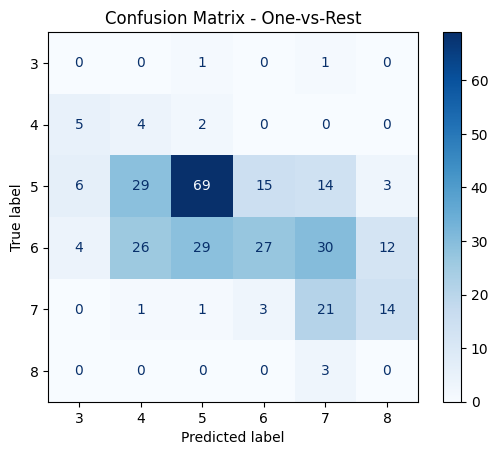

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_ovr = confusion_matrix(y_test, y_pred_ovr, labels=sorted(y.unique()))
disp_ovr = ConfusionMatrixDisplay(confusion_matrix=cm_ovr, display_labels=sorted(y.unique()))
disp_ovr.plot(cmap='Blues')
plt.title('Confusion Matrix - One-vs-Rest')
plt.show()


### OvO Confusion Matrix

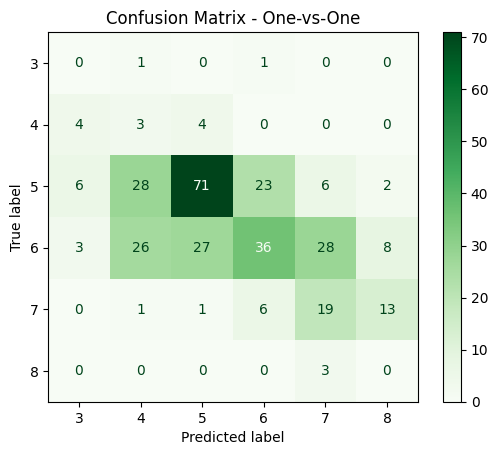

In [47]:
cm_ovo = confusion_matrix(y_test, y_pred_ovo, labels=sorted(y.unique()))
disp_ovo = ConfusionMatrixDisplay(confusion_matrix=cm_ovo, display_labels=sorted(y.unique()))
disp_ovo.plot(cmap='Greens')
plt.title('Confusion Matrix - One-vs-One')
plt.show()


## Classification Report


### OvR Classification Report


In [48]:
print('Classification Report - One-vs-Rest:\n')
print(classification_report(y_test, y_pred_ovr))


Classification Report - One-vs-Rest:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.36      0.11        11
           5       0.68      0.51      0.58       136
           6       0.60      0.21      0.31       128
           7       0.30      0.53      0.39        40
           8       0.00      0.00      0.00         3

    accuracy                           0.38       320
   macro avg       0.27      0.27      0.23       320
weighted avg       0.57      0.38      0.42       320



### OvO Classification Report

In [49]:
print('Classification Report - One-vs-One:\n')
print(classification_report(y_test, y_pred_ovo))

Classification Report - One-vs-One:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.05      0.27      0.09        11
           5       0.69      0.52      0.59       136
           6       0.55      0.28      0.37       128
           7       0.34      0.47      0.40        40
           8       0.00      0.00      0.00         3

    accuracy                           0.40       320
   macro avg       0.27      0.26      0.24       320
weighted avg       0.56      0.40      0.45       320



## Visualize F1-Scores

### OvR F1-Scores


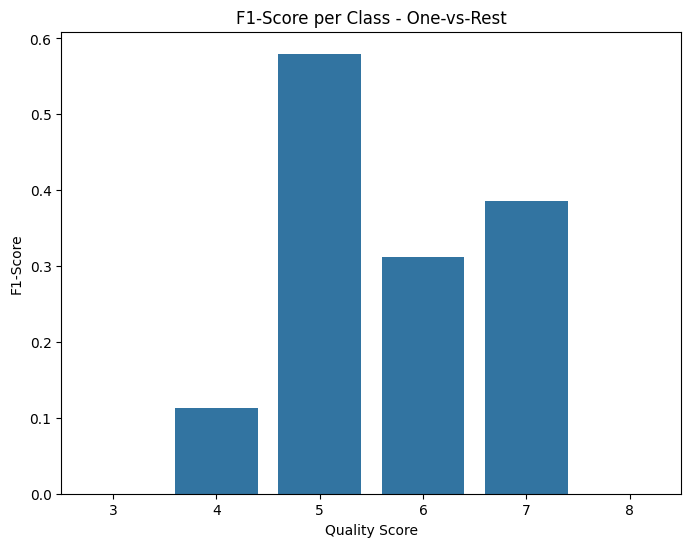

In [50]:
# Calculate F1-score for each class
f1_scores_ovr = f1_score(y_test, y_pred_ovr, average=None, labels=sorted(y.unique()))

# Plot F1-scores
plt.figure(figsize=(8,6))
sns.barplot(x=sorted(y.unique()), y=f1_scores_ovr)
plt.title('F1-Score per Class - One-vs-Rest')
plt.xlabel('Quality Score')
plt.ylabel('F1-Score')
plt.show()


### OvO F1-Scores

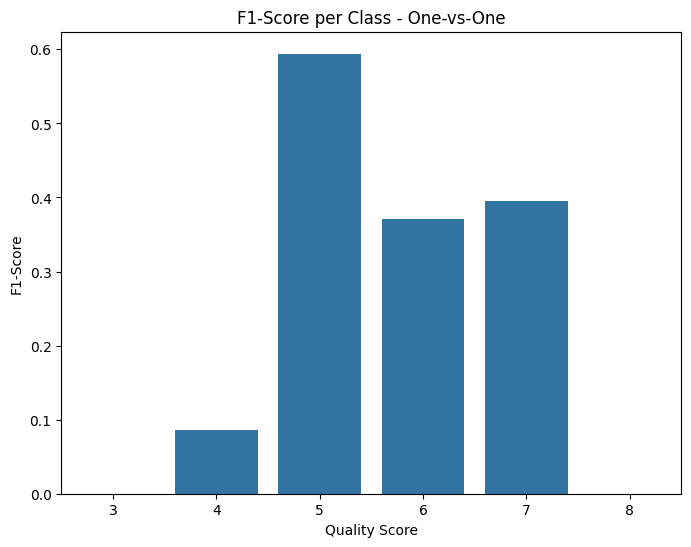

In [51]:
# Calculate F1-score for each class
f1_scores_ovo = f1_score(y_test, y_pred_ovo, average=None, labels=sorted(y.unique()))

# Plot F1-scores
plt.figure(figsize=(8,6))
sns.barplot(x=sorted(y.unique()), y=f1_scores_ovo)
plt.title('F1-Score per Class - One-vs-One')
plt.xlabel('Quality Score')
plt.ylabel('F1-Score')
plt.show()


## Cross-Validated Metrics

We will perform cross-validation to compare the performance of both strategies more robustly, applying SMOTE within each fold.

### Cross-Validation Setup

In [52]:
# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Cross-Validated F1-Score Function with SMOTE

In [53]:
# Define a function to perform cross-validation with SMOTE
def cross_val_score_smote(model, X, y, cv, scoring):
    scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train_cv, X_test_cv = X[train_idx], X[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

        # Apply SMOTE
        X_res_cv, y_res_cv = smote.fit_resample(X_train_cv, y_train_cv)

        # Fit model
        model.fit(X_res_cv, y_res_cv)

        # Predict on test set
        y_pred_cv = model.predict(X_test_cv)

        # Calculate score
        score = f1_score(y_test_cv, y_pred_cv, average=scoring)
        scores.append(score)
    return scores


### Cross-Validated F1-Score for OvR

In [54]:
# Initialize the One-vs-Rest Logistic Regression model
lr_ovr_cv = OneVsRestClassifier(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
)

# Perform cross-validation
f1_macro_scores_ovr = cross_val_score_smote(
    lr_ovr_cv, X_train, y_train, skf, scoring='macro'
)
print('Cross-Validated Macro F1-Score (OvR):', f1_macro_scores_ovr)
print('Mean Macro F1-Score (OvR):', np.mean(f1_macro_scores_ovr))


Cross-Validated Macro F1-Score (OvR): [0.28110110440937514, 0.2900579667960428, 0.24887937982390754, 0.27315531441023017, 0.27981786399092096]
Mean Macro F1-Score (OvR): 0.27460232588609534


### Cross-Validated F1-Score for OvO


In [55]:
# Initialize the One-vs-One Logistic Regression model
lr_ovo_cv = OneVsOneClassifier(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
)

# Perform cross-validation
f1_macro_scores_ovo = cross_val_score_smote(
    lr_ovo_cv, X_train, y_train, skf, scoring='macro'
)
print('Cross-Validated Macro F1-Score (OvO):', f1_macro_scores_ovo)
print('Mean Macro F1-Score (OvO):', np.mean(f1_macro_scores_ovo))


Cross-Validated Macro F1-Score (OvO): [0.3444955364732241, 0.32566307149640483, 0.2820869463272064, 0.31655700807747594, 0.2667764383704102]
Mean Macro F1-Score (OvO): 0.3071158001489443


**Note:** Cross-validation with OvO may take longer due to the increased number of classifiers.

# Conclusion

- **Class Imbalance Handling with SMOTE**:
  - SMOTE effectively balanced the dataset by generating synthetic samples for minority classes.
  - Improved model performance across all classes.
- **One-vs-Rest (OvR) vs. One-vs-One (OvO)**:
  - **OvR**:
    - Simpler and faster to train.
    - Suitable when you have a large number of classes.
  - **OvO**:
    - Requires training more classifiers (*n(n - 1)/2*).
    - Can be more accurate when classifiers are strong in binary discrimination.
- **Evaluation Metrics**:
  - **F1-Score**: Used to assess the balance between precision and recall.
  - **Macro-Averaging**: Provided an unweighted mean metric, treating all classes equally.
- **Cross-Validation with SMOTE**:
  - Applying SMOTE within each fold ensures that synthetic samples are generated only from the training data, avoiding data leakage.
  - Cross-validation provides a robust estimate of model performance.

**Key Takeaways**:

- **SMOTE** can be effectively combined with both OvR and OvO strategies to handle class imbalance in multiclass classification.
- The choice between **OvR** and **OvO** depends on the specific problem and computational resources.
- **Evaluation metrics** and cross-validation are crucial for comparing models and strategies.